In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_path = "../data/cs-training.csv"
test_path = "../data/cs-test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(train.shape)
print(test.shape)

train.head()

(150000, 12)
(101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [17]:
#删除无用列
train = train.drop(columns=["Unnamed: 0"])
test = test.drop(columns=["Unnamed: 0"])

train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [18]:
#查看字段信息
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [19]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_rate = train.isnull().mean().sort_values(ascending=False)

pd.DataFrame({
    "missing_count": missing,
    "missing_rate": missing_rate
})

,missing_count,missing_rate
MonthlyIncome,29731,0.198207
NumberOfDependents,3924,0.026160
SeriousDlqin2yrs,0,0.000000
age,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
DebtRatio,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000


In [20]:
#查看目标变量分布
train["SeriousDlqin2yrs"].value_counts()
train["SeriousDlqin2yrs"].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

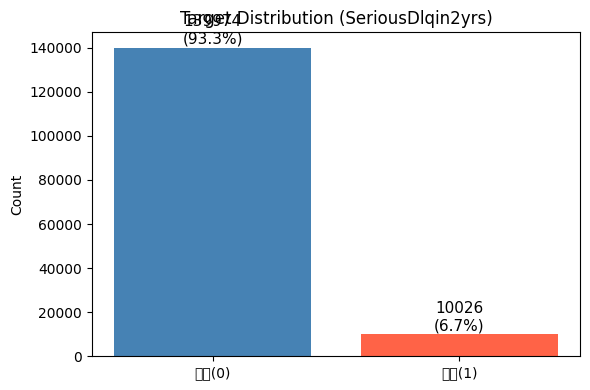

In [21]:
#画目标变量分布图（含百分比标注）
counts = train["SeriousDlqin2yrs"].value_counts()
total = len(train)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["正常(0)", "违约(1)"], counts.values, color=["steelblue", "tomato"])
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{cnt}\n({cnt/total:.1%})", ha="center", va="bottom", fontsize=11)
ax.set_title("Target Distribution (SeriousDlqin2yrs)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 1. 基础统计描述

In [22]:
train.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.0668,0.2497,0.0,0.0000,0.0000,0.0000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.0484,249.7554,0.0,0.0299,0.1542,0.5590,50708.0
age,150000.0,52.2952,14.7719,0.0,41.0000,52.0000,63.0000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.4210,4.1928,0.0,0.0000,0.0000,0.0000,98.0
DebtRatio,150000.0,353.0051,2037.8185,0.0,0.1751,0.3665,0.8683,329664.0
MonthlyIncome,120269.0,6670.2212,14384.6742,0.0,3400.0000,5400.0000,8249.0000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.4528,5.1460,0.0,5.0000,8.0000,11.0000,58.0
NumberOfTimes90DaysLate,150000.0,0.2660,4.1693,0.0,0.0000,0.0000,0.0000,98.0
NumberRealEstateLoansOrLines,150000.0,1.0182,1.1298,0.0,0.0000,1.0000,2.0000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.2404,4.1552,0.0,0.0000,0.0000,0.0000,98.0


## 2. 重复行检查

In [23]:
dup_count = train.duplicated().sum()
print(f"重复行数量: {dup_count}")

重复行数量: 609


## 3. 异常值检测

已知该数据集存在以下数据质量问题：
- `age = 0`：不合理的年龄值
- `RevolvingUtilizationOfUnsecuredLines > 1`：信用使用率理论上应在 [0, 1]
- `DebtRatio` 极大值：部分记录负债比远超正常范围
- 逾期次数字段中出现 96 / 98：疑似特殊编码（如「不适用」或「拒绝回答」）

In [24]:
print("=== 异常值检测 ===")
print(f"age == 0 的记录数: {(train['age'] == 0).sum()}")
print(f"RevolvingUtilizationOfUnsecuredLines > 1 的记录数: {(train['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()}")
print(f"DebtRatio > 1 的记录数: {(train['DebtRatio'] > 1).sum()}")
print(f"DebtRatio 最大值: {train['DebtRatio'].max():.2f}")

print("\nNumberOfTime30-59DaysPastDueNotWorse 值分布（降序前10）:")
print(train["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index(ascending=False).head(10))

print("\nNumberOfTime60-89DaysPastDueNotWorse 值分布（降序前10）:")
print(train["NumberOfTime60-89DaysPastDueNotWorse"].value_counts().sort_index(ascending=False).head(10))

print("\nNumberOfTimes90DaysLate 值分布（降序前10）:")
print(train["NumberOfTimes90DaysLate"].value_counts().sort_index(ascending=False).head(10))

=== 异常值检测 ===
age == 0 的记录数: 1
RevolvingUtilizationOfUnsecuredLines > 1 的记录数: 3321
DebtRatio > 1 的记录数: 35137
DebtRatio 最大值: 329664.00

NumberOfTime30-59DaysPastDueNotWorse 值分布（降序前10）:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
10      4
9      12
8      25
7      54
6     140
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse 值分布（降序前10）:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
7       9
6      16
5      34
4     105
3     318
Name: count, dtype: int64

NumberOfTimes90DaysLate 值分布（降序前10）:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
13      4
12      2
11      5
10      8
9      19
Name: count, dtype: int64


## 4. 数值特征分布

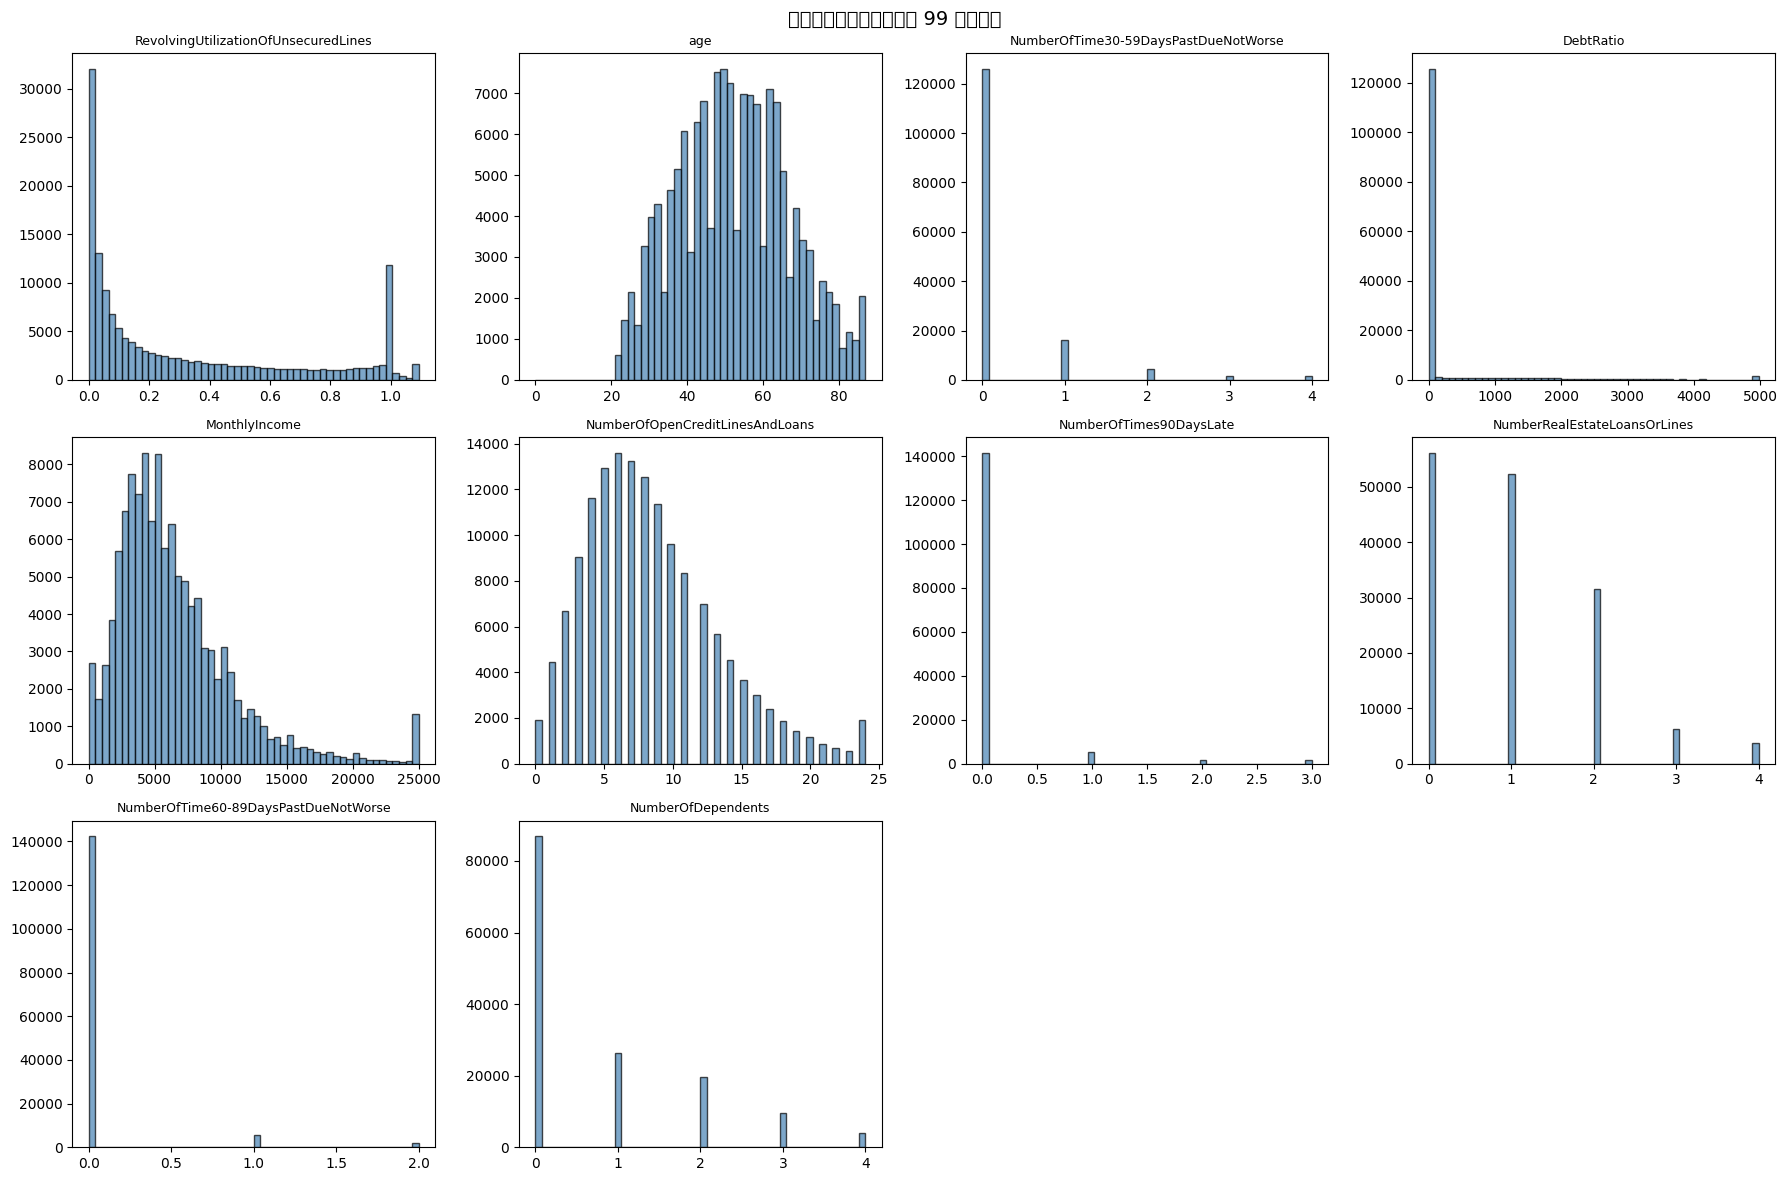

In [25]:
import warnings
warnings.filterwarnings("ignore")

features = [col for col in train.columns if col != "SeriousDlqin2yrs"]
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # 使用 99 分位数裁剪，避免极端值压缩主体分布
    upper = train[col].quantile(0.99)
    data = train[col].clip(upper=upper).dropna()
    axes[i].hist(data, bins=50, edgecolor="k", alpha=0.7, color="steelblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("数值特征分布（已裁剪至 99 分位数）", fontsize=14)
plt.tight_layout()
plt.show()

## 5. 特征与目标变量的双变量分析

In [26]:
# 按目标分组的特征均值对比
group_stats = train.groupby("SeriousDlqin2yrs").mean().T
group_stats.columns = ["正常(0)", "违约(1)"]
group_stats["违约/正常 比值"] = (group_stats["违约(1)"] / group_stats["正常(0)"]).round(3)
group_stats.round(4)

,正常(0),违约(1),违约/正常 比值
RevolvingUtilizationOfUnsecuredLines,6.1689,4.3673,0.708
age,52.7514,45.9266,0.871
NumberOfTime30-59DaysPastDueNotWorse,0.2801,2.3885,8.527
DebtRatio,357.1512,295.1211,0.826
MonthlyIncome,6747.8378,5630.8265,0.834
NumberOfOpenCreditLinesAndLoans,8.4936,7.8823,0.928
NumberOfTimes90DaysLate,0.1352,2.0914,15.466
NumberRealEstateLoansOrLines,1.0204,0.9885,0.969
NumberOfTime60-89DaysPastDueNotWorse,0.1267,1.8280,14.432
NumberOfDependents,0.7434,0.9482,1.275


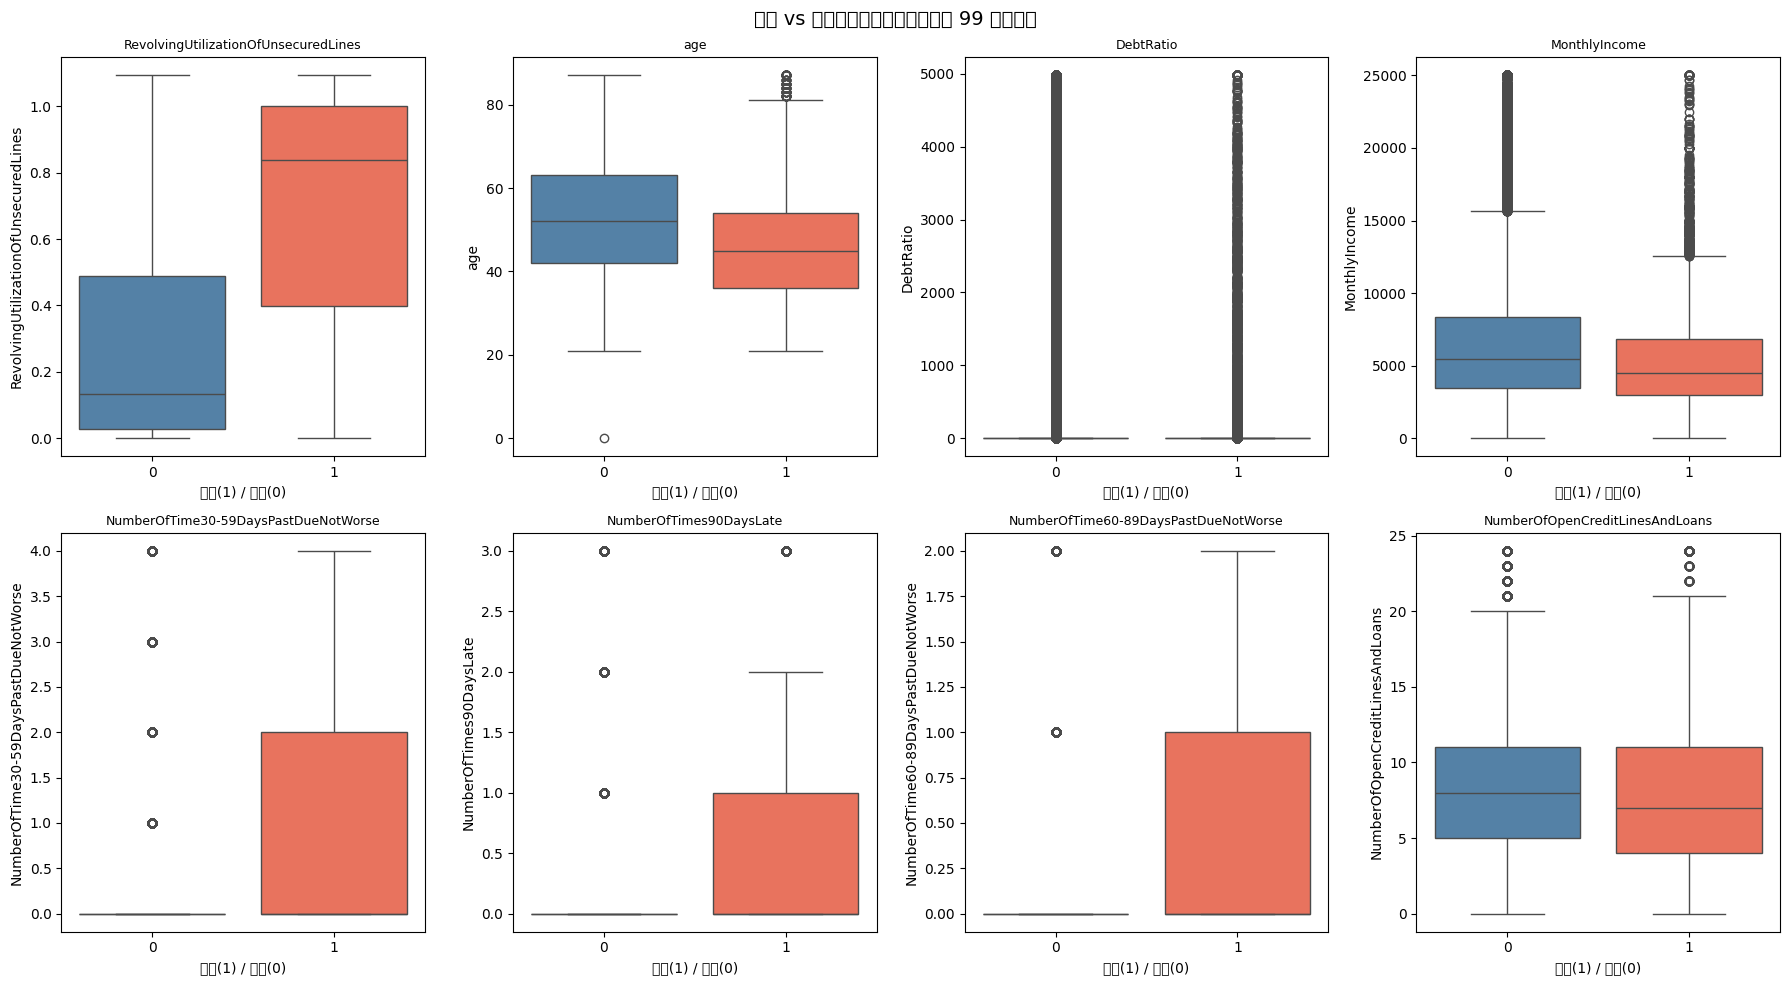

In [27]:
import seaborn as sns

key_features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    upper = train[col].quantile(0.99)
    data_clip = train[[col, "SeriousDlqin2yrs"]].copy()
    data_clip[col] = data_clip[col].clip(upper=upper)
    sns.boxplot(x="SeriousDlqin2yrs", y=col, data=data_clip, ax=axes[i],
                palette=["steelblue", "tomato"])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("违约(1) / 正常(0)")

plt.suptitle("特征 vs 目标变量箱线图（已裁剪至 99 分位数）", fontsize=14)
plt.tight_layout()
plt.show()

## 6. 特征相关性热力图

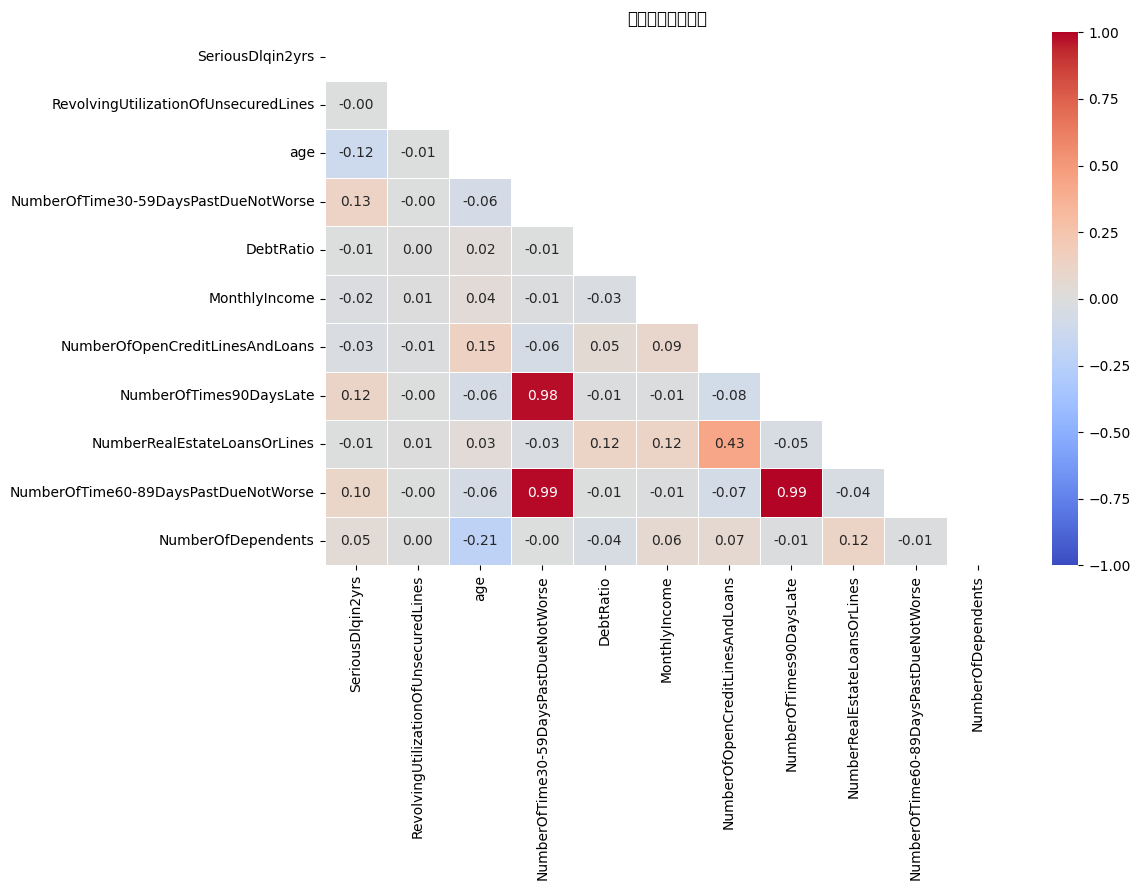

In [28]:
plt.figure(figsize=(12, 9))
corr = train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    mask=mask, vmin=-1, vmax=1, linewidths=0.5
)
plt.title("特征相关性热力图")
plt.tight_layout()
plt.show()

## 7. 缺失值与目标变量的关系

判断缺失是否为非随机缺失（MAR），影响后续填补策略。

In [29]:
for col in ["MonthlyIncome", "NumberOfDependents"]:
    flag = f"{col}_missing"
    temp = train.copy()
    temp[flag] = temp[col].isnull().astype(int)
    rate = temp.groupby(flag)["SeriousDlqin2yrs"].mean()
    count = temp.groupby(flag)["SeriousDlqin2yrs"].count()
    result = pd.DataFrame({"违约率": rate, "样本量": count})
    result.index = [f"{col} 有值", f"{col} 缺失"]
    print(f"\n{col}:")
    print(result.to_string())


MonthlyIncome:
                       违约率     样本量
MonthlyIncome 有值  0.069486  120269
MonthlyIncome 缺失  0.056137   29731

NumberOfDependents:
                            违约率     样本量
NumberOfDependents 有值  0.067410  146076
NumberOfDependents 缺失  0.045617    3924


## 8. 训练集 vs 测试集分布对比

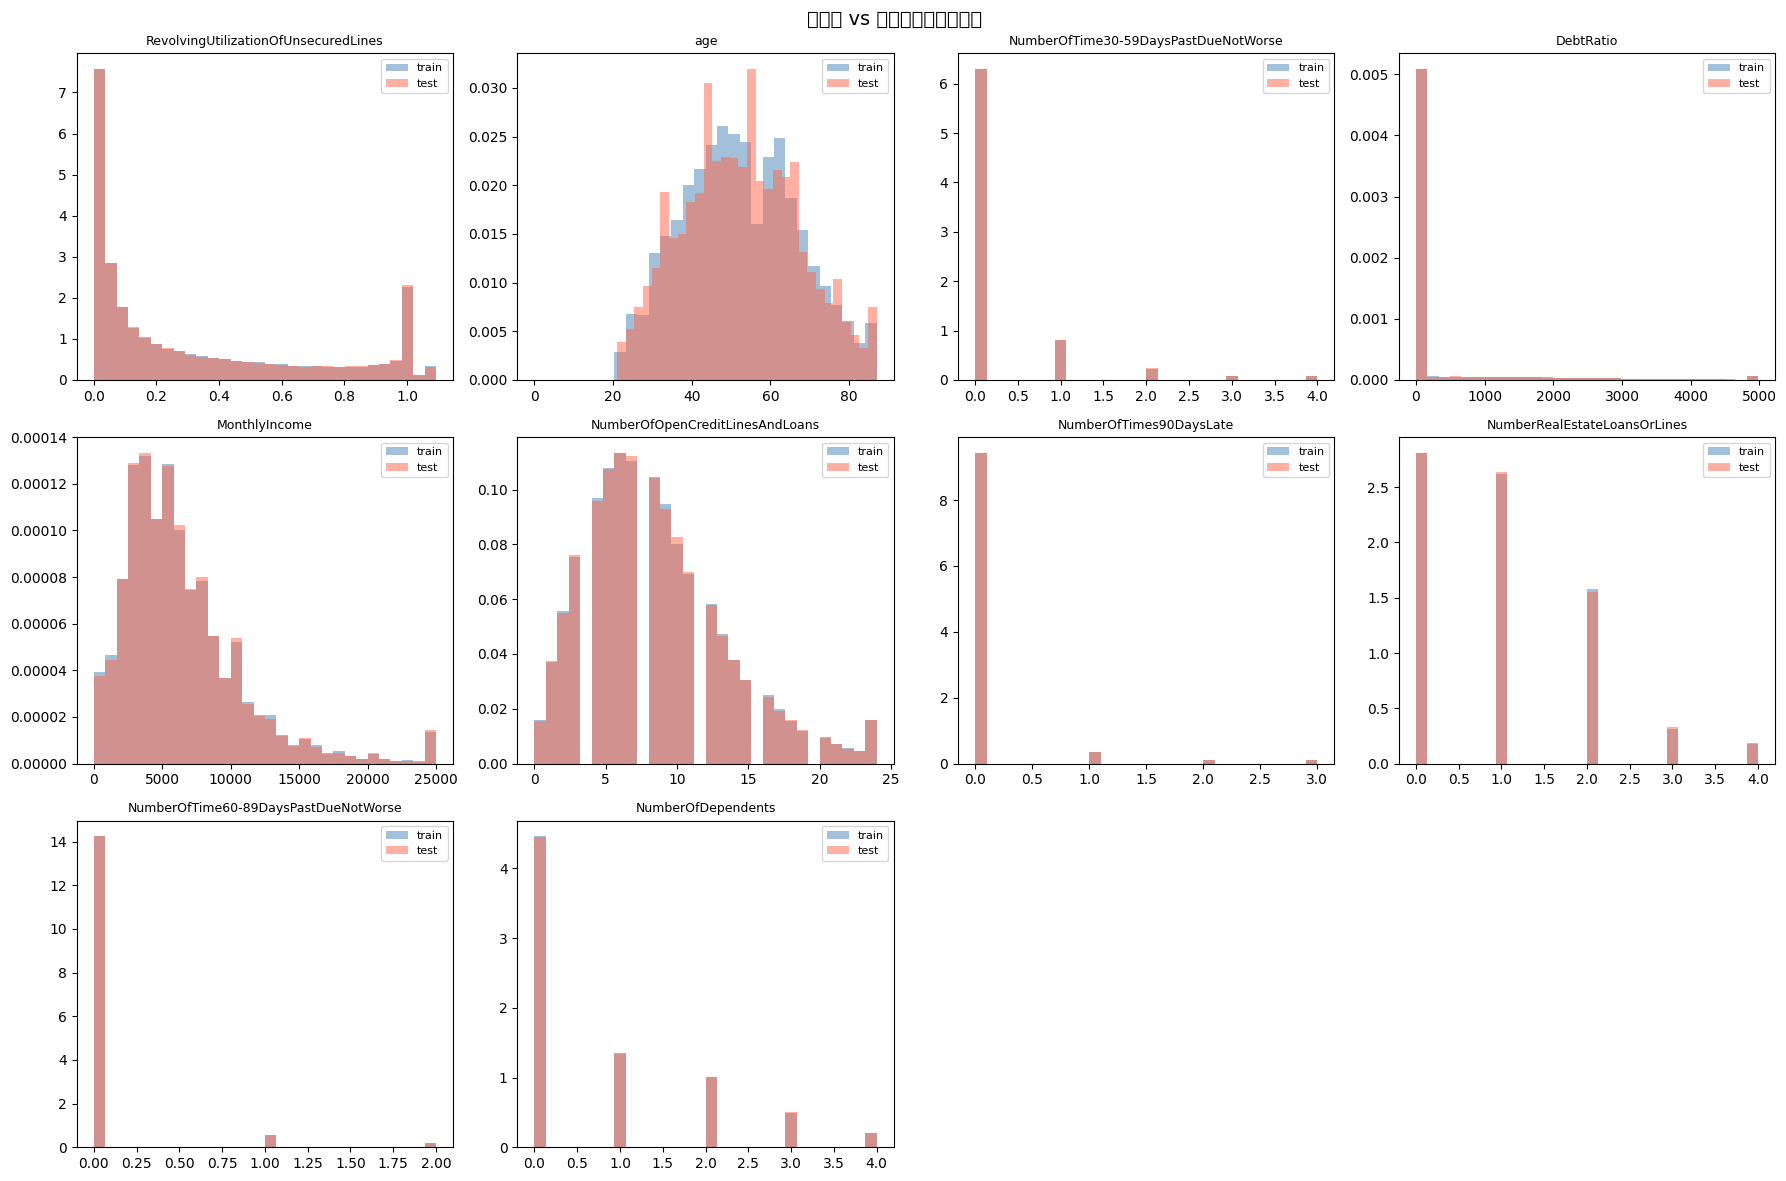

In [30]:
features_to_compare = [col for col in train.columns if col != "SeriousDlqin2yrs"]
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_compare):
    upper = train[col].quantile(0.99)
    axes[i].hist(
        train[col].clip(upper=upper).dropna(),
        bins=30, alpha=0.5, label="train", density=True, color="steelblue"
    )
    axes[i].hist(
        test[col].clip(upper=upper).dropna(),
        bins=30, alpha=0.5, label="test", density=True, color="tomato"
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=8)

for j in range(len(features_to_compare), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("训练集 vs 测试集特征分布对比", fontsize=14)
plt.tight_layout()
plt.show()

## EDA 总结

### 数据集概况

| 项目 | 训练集 | 测试集 |
|------|--------|--------|
| 样本量 | 150,000 | 101,503 |
| 特征数 | 10 | 10 |
| 目标变量 | SeriousDlqin2yrs（有标签） | 无标签 |

---

### 1. 类别不平衡

- 违约率约为 **6.68%**，正负样本比约为 **14:1**
- 后续建模需处理不平衡问题，可选方案：`class_weight='balanced'`、SMOTE 过采样、调整决策阈值

---

### 2. 缺失值

| 字段 | 缺失率 | 建议处理方式 |
|------|--------|--------------|
| MonthlyIncome | ~19.8% | 按分组中位数填充；保留 `MonthlyIncome_missing` 标记特征 |
| NumberOfDependents | ~2.6% | 众数（0）或中位数填充 |

- 若缺失与违约率相关（MAR），则需保留缺失标记特征参与建模

---

### 3. 异常值（数据质量问题）

| 字段 | 异常情况 | 建议处理 |
|------|----------|----------|
| age | 存在 age=0 的记录 | 替换为 NaN 后填中位数 |
| RevolvingUtilizationOfUnsecuredLines | 部分值远大于 1 | 截断至 1，或保留作为高风险信号 |
| DebtRatio | 极大值（可达数千） | 对数变换（log1p）或上分位数截断 |
| 三个逾期次数字段 | 出现 96 / 98（疑似特殊编码） | 替换为 NaN 或单独编码为二值标志 |

---

### 4. 特征与目标的关系

- **强正相关**（违约组均值显著高于正常组）：
  - `NumberOfTimes90DaysLate`
  - `NumberOfTime60-89DaysPastDueNotWorse`
  - `NumberOfTime30-59DaysPastDueNotWorse`
  - `RevolvingUtilizationOfUnsecuredLines`
- **负相关**（违约组均值低于正常组）：
  - `age`（年龄越大，违约率越低）
  - `MonthlyIncome`（收入越高，违约率越低）
- 三个逾期字段之间高度相关，可考虑合并或构造聚合特征

---

### 5. 特征分布特点

| 特征 | 分布特点 | 建议 |
|------|----------|------|
| MonthlyIncome | 严重右偏 | log1p 变换 |
| DebtRatio | 严重右偏，含极大值 | log1p + 截断 |
| RevolvingUtilizationOfUnsecuredLines | 双峰（集中在 0 和 1） | 可分箱或保持原值 |
| 三个逾期次数字段 | 零膨胀，绝大多数为 0 | 构造二值化特征（是否曾逾期） |

---

### 6. 训练集 vs 测试集

- 整体特征分布基本一致，无明显 distribution shift
- 测试集无标签，用于最终提交预测

---

### 后续特征工程建议（优先级排序）

1. **P0** 修正异常值：`age=0` → NaN；逾期次数 96/98 → NaN
2. **P0** 对数变换右偏特征：`MonthlyIncome`、`DebtRatio`
3. **P1** 构造缺失标记：`MonthlyIncome_missing`
4. **P1** 截断极端值：`RevolvingUtilizationOfUnsecuredLines` clip to [0, 1]
5. **P1** 构造逾期二值特征：`ever_late_30/60/90`（是否曾发生对应逾期）
6. **P2** 合并三个逾期字段为总逾期次数特征